# Notebook 07 — Correlation Analysis

### Crypto Alpha Research Lab (CARL)

This notebook examines the linear relationships among Bitcoin market variables using correlation analysis. Understanding these relationships provides insight into how price movements, trading activity, and return dynamics interact, supporting subsequent feature selection and predictive modeling.

### Research Objective

The objectives of this notebook are to:

- Construct market features for analysis.
- Estimate pairwise Pearson correlations.
- Visualize the correlation matrix.
- Identify relationships among price, returns, volatility, and trading volume.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

from asset_pricing_lab.risk import standard_deviation
from asset_pricing_lab.returns import arithmetic_returns

In [4]:
TICKER = "BTC-USD"

START_DATE = "2020-01-01"
END_DATE = "2026-06-20"

INTERVAL = "1d"

AUTO_ADJUST = True

REFRESH_CACHE = True

In [5]:
from crypto_alpha_lab.data.storage import load_prices

btc = load_prices(
    ticker="BTC-USD",
    start="2020-01-01",
    end="2026-06-20",
    interval="1d",
)

btc.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [11]:
btc['Return'] = arithmetic_returns(btc["Close"]).dropna()

In [10]:
btc.head()

Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,NaN
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,-0.029819
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.051452
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.008955
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.000089


In [12]:
btc["Volatility"] = (
    btc["Return"]
    .rolling(window=30)
    .apply(standard_deviation, raw=False)
)

The selected variables capture complementary dimensions of Bitcoin market behavior, including price dynamics, return generation, realized risk, and trading activity. Together, these features provide a robust foundation for evaluating linear dependence across market characteristics.

In [13]:
features = btc[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Return",
        "Volatility",
    ]
]

In [14]:
correlation = features.corr()

correlation

Price,Open,High,Low,Close,Volume,Return,Volatility
Price,,,,,,,
Open,1.000000,0.999441,0.999171,0.998808,0.425940,-0.047129,-0.298475
High,0.999441,1.000000,0.998965,0.999469,0.435237,-0.025806,-0.291821
Low,0.999171,0.998965,1.000000,0.999377,0.409728,-0.023776,-0.306200
Close,0.998808,0.999469,0.999377,1.000000,0.423690,-0.006244,-0.297964
Volume,0.425940,0.435237,0.409728,0.423690,1.000000,-0.027108,0.157570
Return,-0.047129,-0.025806,-0.023776,-0.006244,-0.027108,1.000000,0.019722
Volatility,-0.298475,-0.291821,-0.306200,-0.297964,0.157570,0.019722,1.000000


The Pearson correlation matrix measures the strength and direction of linear relationships among market variables. Strong correlations may indicate overlapping information, whereas weaker relationships suggest variables that contribute complementary information for quantitative modeling.

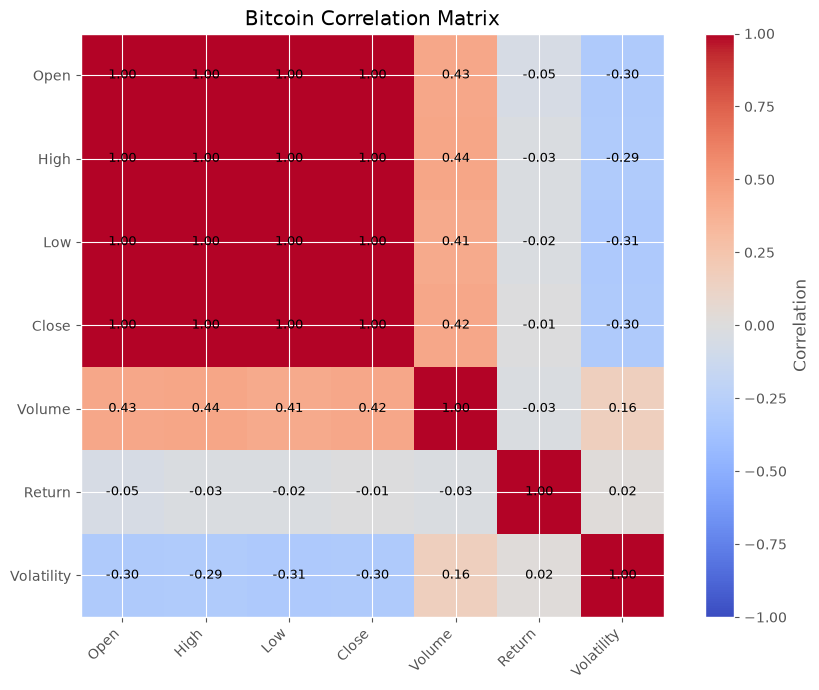

In [15]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns,
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
        )

plt.title("Bitcoin Correlation Matrix")

plt.tight_layout()

plt.show()

### Interpretation

The correlation matrix summarizes the linear dependence among Bitcoin market variables. Price-based variables are expected to exhibit strong positive correlations because they capture related aspects of the same trading process, while returns, realized volatility, and trading volume provide additional information about market behavior. These relationships form an important basis for feature selection, risk modeling, and the development of quantitative trading strategies.